# Step 1 - Load all necessary modules

In [1]:
#! pip install numpy scipy matplotlib ipython
import os
import numpy as np
import scipy
import scipy.io.wavfile as wav
import scipy.fftpack as fft
from scipy.signal import get_window
import IPython.display as ipd
import matplotlib.pyplot as plt

%matplotlib inline

# Step 2 - Load and Visualize A sample Data 

In [2]:
# Define the path to the audio file
record = './../../data/wav/'
# Load the audio file
sample1 = record+'emergency/emergency_06.wav'
sample2 = record+'nourishment/nourishment_33.wav'
sample3 = record+'assistance/assistance_11.wav'
# Display the audio file
sample = sample2
voice_sample = ipd.Audio(sample)
voice_sample

In [3]:
# Display summary information of the audio sample
sample_rate, signal1 = wav.read(sample1)
sample_rate, signal2 = wav.read(sample2)
sample_rate, signal3 = wav.read(sample3)
print("Overall:")
print(f"Sample rate: {sample_rate} Hz")
print(f"Length of signal: {len(signal1)} samples")
print(f"Recording duration: {len(signal1)/sample_rate:.2f} seconds")

print("\nDetailed information:")
print("--------------------")
print("Help:")
print(f"Max amplitude: {max(signal1)}")
print(f"Min amplitude: {min(signal1)}")
print(f"Mean amplitude: {np.mean(signal1):.2f}")

print("Water:")
print(f"Max amplitude: {max(signal2)}")
print(f"Min amplitude: {min(signal2)}")
print(f"Mean amplitude: {np.mean(signal2):.2f}")

print("Bathroom:")
print(f"Max amplitude: {max(signal3)}")
print(f"Min amplitude: {min(signal3)}")
print(f"Mean amplitude: {np.mean(signal3):.2f}")


Overall:
Sample rate: 16000 Hz
Length of signal: 48000 samples
Recording duration: 3.00 seconds

Detailed information:
--------------------
Help:
Max amplitude: 17503
Min amplitude: -25328
Mean amplitude: 1120.86
Water:
Max amplitude: 18388
Min amplitude: -16512
Mean amplitude: -408.88
Bathroom:
Max amplitude: 8548
Min amplitude: -12559
Mean amplitude: 453.94


In [4]:
def plot_waveform(signals=[],x_label='Time', tittle="Waveform of Audio Signals"):
    #plt.title(tittle,fontsize=14)
    plt.subplot(3,1,1)
    plt.plot(signals[0])
    plt.xlabel(x_label)
    plt.ylabel("Help's Amplitude")
    plt.tight_layout(pad=1.5)

    plt.subplot(3,1,2)
    plt.plot(signals[1])

    plt.xlabel(x_label)
    plt.ylabel("Water's Amplitude")
    plt.tight_layout(pad=1.5)

    plt.subplot(3,1,3)
    plt.plot(signals[2])

    plt.xlabel(x_label)
    plt.ylabel("Bathroom's Amplitude")
    plt.tight_layout(pad=1.5)

    
    plt.show()
    

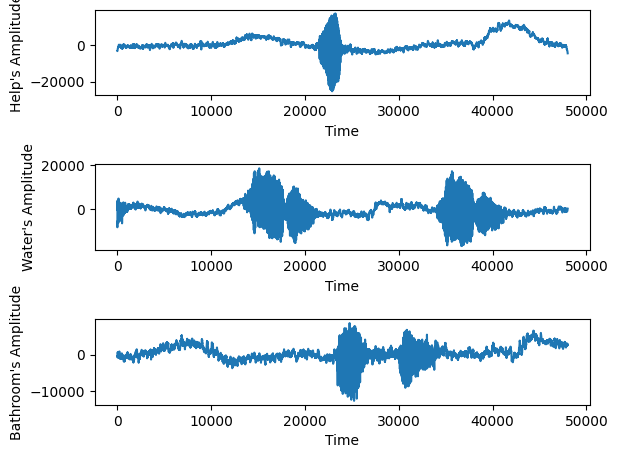

In [5]:
raw_signals = [signal1, signal2, signal3]
plot_waveform(raw_signals,'Time', "Waveform of Raw Audio Signals")

# Step 3 - Pre-emphasis

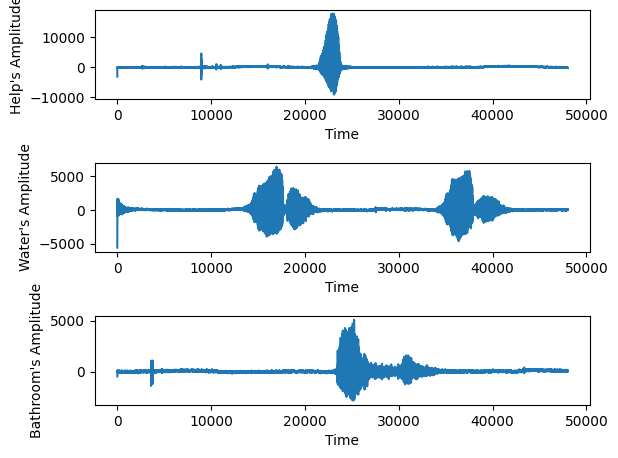

In [6]:
# Apply pre-emphasis filter to balance the frequency spectrum
pre_emphasis = 0.97
emphasized_signal1 = np.append(signal1[0], signal1[1:] - pre_emphasis * signal1[:-1])
emphasized_signal2 = np.append(signal2[0], signal2[1:] - pre_emphasis * signal2[:-1])
emphasized_signal3 = np.append(signal3[0], signal3[1:] - pre_emphasis * signal3[:-1])
emphasized_signals = [emphasized_signal1, emphasized_signal2, emphasized_signal3]
plot_waveform(emphasized_signals,'Time', "Waveform of Emphasized Audio Signals")

# Step 4 - Signal Segmentation with Framing and Windowing

In [7]:

# Break the audio signal into 25ms frames with 10ms overlap
frame_size = 0.025
frame_stride = 0.01
frame_len = int(round(frame_size*sample_rate))
frame_step = int(round(frame_stride*sample_rate))

def framing(signal,frame_len,frame_step):
    # compute number of frames
    signal_len = len(signal)
    num_frames = int(np.ceil(float(np.abs(signal_len - frame_len)) / frame_step))

    # Pad signal to ensure all frames have equal number of samples
    pad_len = num_frames * frame_step + frame_len
    z = np.zeros((pad_len - signal_len))

    pad_signal = np.append(signal, z)

    # Slice signal into frames using indices
    ## make a single frame [0,1,2,...,frame_len-1]
    single_frame = np.arange(0, frame_len)
    ## duplicate the single frame num_frames times
    ### output: [[0,1,2,...,frame_len-1],
    ###          [0,1,2,...,frame_len-1],
    ###          ...] (num_frames rows)
    n_frames = np.tile(single_frame, (num_frames, 1))

    ## create starting indices for each frame
    frame_idx= np.arange(0, num_frames * frame_step, frame_step)
    ### repeat frame_idx for frame_len times and transpose to get the same shape as n_frames
    frame_idx = np.tile(frame_idx, (frame_len, 1)).T

    row_indices = n_frames + frame_idx
    frames = pad_signal[row_indices.astype(np.int32, copy=False)]
    frames *= np.hamming(frame_len) 
    return frames


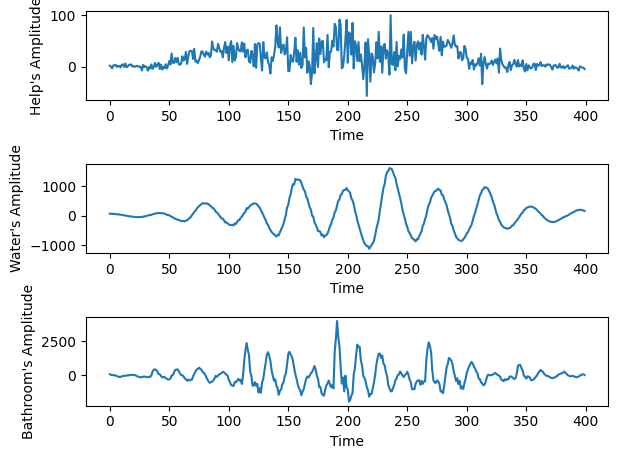

In [8]:
help_frames = framing(emphasized_signal1, frame_len, frame_step)
water_frames = framing(emphasized_signal2, frame_len, frame_step)
bathroom_frames = framing(emphasized_signal3, frame_len, frame_step)
framed_signals = [help_frames, water_frames, bathroom_frames]

# plot some sample frames to visualize the effect of framing
sample_frames = [help_frames[int(len(help_frames)*0.4)], water_frames[int(len(water_frames)*0.3)], bathroom_frames[int(len(bathroom_frames)*0.5)]]
plot_waveform(sample_frames,'Time', "Waveform of Framed Audio Signals")

# Step 5 - Time-to-Frequency Conversion with Fast Fourier Transform (FFT)

In [9]:
def ttf_conversion(frames,NFFT):
    # Compute the magnitude spectrum of each frame using FFT
    mag_frames = np.absolute(np.fft.rfft(frames, NFFT))
    # Compute the power spectrum of each frame
    pow_frames = ((1.0 / NFFT) * (mag_frames ** 2))
    return pow_frames

help_pow_frames = ttf_conversion(help_frames, 512)
water_pow_frames = ttf_conversion(water_frames, 512)
bathroom_pow_frames = ttf_conversion(bathroom_frames, 512)
pow_frames = [help_pow_frames, water_pow_frames, bathroom_pow_frames]


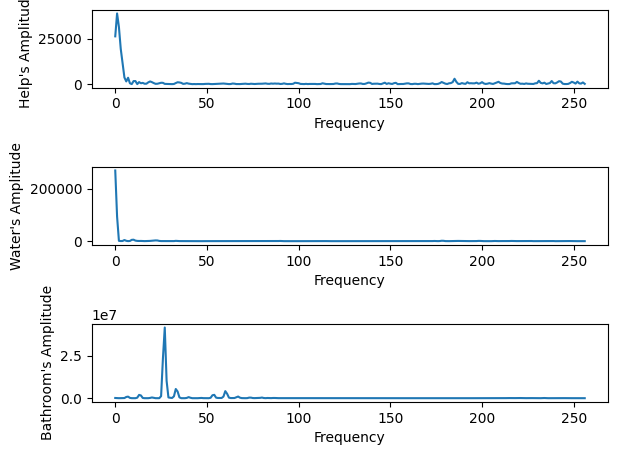

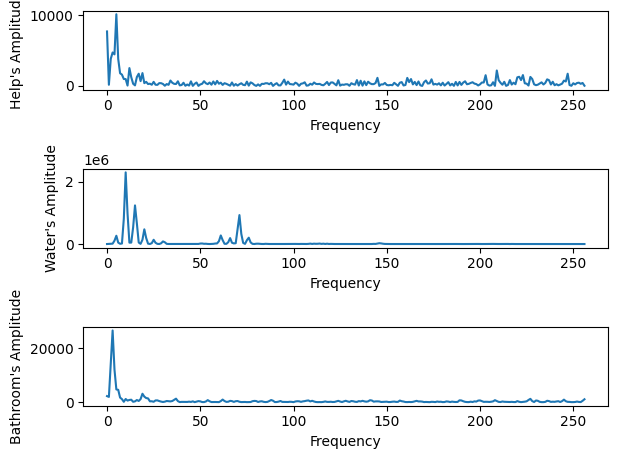

In [10]:
# plot the power spectrum of a sample frame to visualize the effect of FFT
sample_pow_frames = [help_pow_frames[int(len(help_pow_frames)*0.2)], water_pow_frames[int(len(water_pow_frames)*0.2)], bathroom_pow_frames[int(len(bathroom_pow_frames)*0.5)]]
plot_waveform(sample_pow_frames,'Frequency', "Power Spectrum of Sample Frames")
sample_pow_frames = [help_pow_frames[0], water_pow_frames[0], bathroom_pow_frames[0]]
plot_waveform(sample_pow_frames, 'Frequency', "Power Spectrum of Sample Frames")

# Step 6 - Human Pitch Mimicking with Mel-Filterbank

In [11]:
def mel_filter_bank(pow_frames, sample_rate, NFFT, num_filters):
    # mel scale = 2595*log10(1+frequency/700)
    mel_scale = lambda f: 2595 * np.log10(1+f/700)
    # Convert the frequency range to mel scale
    hz_points = lambda m: 700*(10**(m/2595)-1)

    mels = np.linspace(mel_scale(0), mel_scale(sample_rate/2), num_filters + 2)
    freqs = hz_points(mels)

    # Scale the frequencies to corresponding bin indices in the FFT output
    bins = np.floor((NFFT + 1) * freqs / sample_rate).astype(int)

    # Create the filters for each frequency bin
    filters = np.zeros((num_filters,int(np.floor(NFFT/2 +1))))
    for i in range(1, num_filters + 1):
        left = int(bins[i-1])
        center = int(bins[i])
        right = int(bins[i+1])
        for j in range(left, center):
            filters[i-1, j] = (j - bins[i-1]) / (bins[i] - bins[i-1])
        for j in range(center, right):
            filters[i-1, j] = (bins[i+1] - j) / (bins[i+1] - bins[i])

    # Create the filter bank by computing the dot product of the power spectrum and the filters
    filter_banks = np.dot(pow_frames, filters.T)
    # Avoid log of zero
    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks) 
    
    return filter_banks

In [12]:
help_banks = mel_filter_bank(help_pow_frames, sample_rate, 512, 40)
water_banks = mel_filter_bank(water_pow_frames, sample_rate, 512, 40)
bathroom_banks = mel_filter_bank(bathroom_pow_frames, sample_rate, 512, 40)

filter_banks = [help_banks, water_banks, bathroom_banks]

# Step 7 - Logarithmic Scaling the Mel-Filterbank

In [13]:
def logarithmic_scale(filter_banks):
    # Take the logarithm of the filter bank energies
    log_filter_banks = 20*np.log10(filter_banks)
    
    return log_filter_banks


In [14]:
log_filter_banks = [logarithmic_scale(bank) for bank in filter_banks]

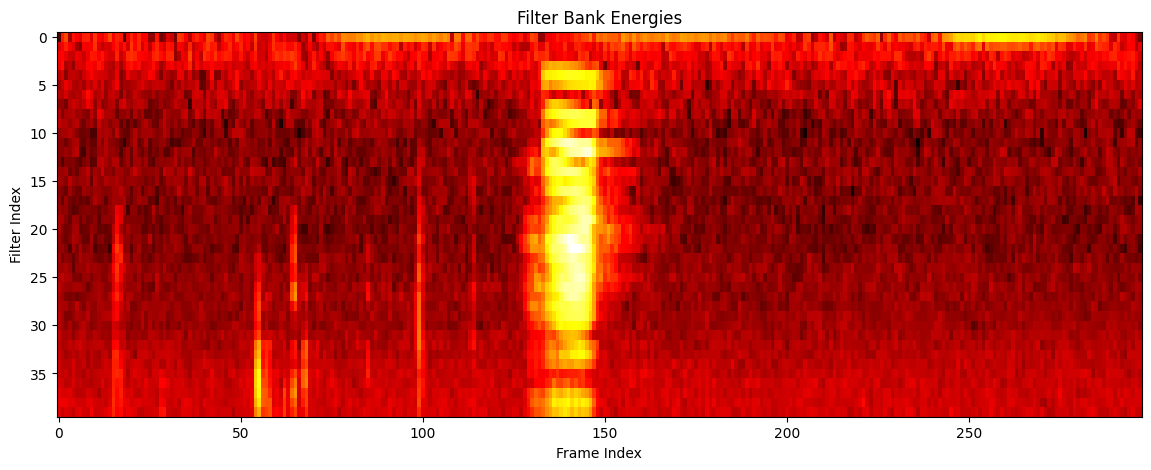

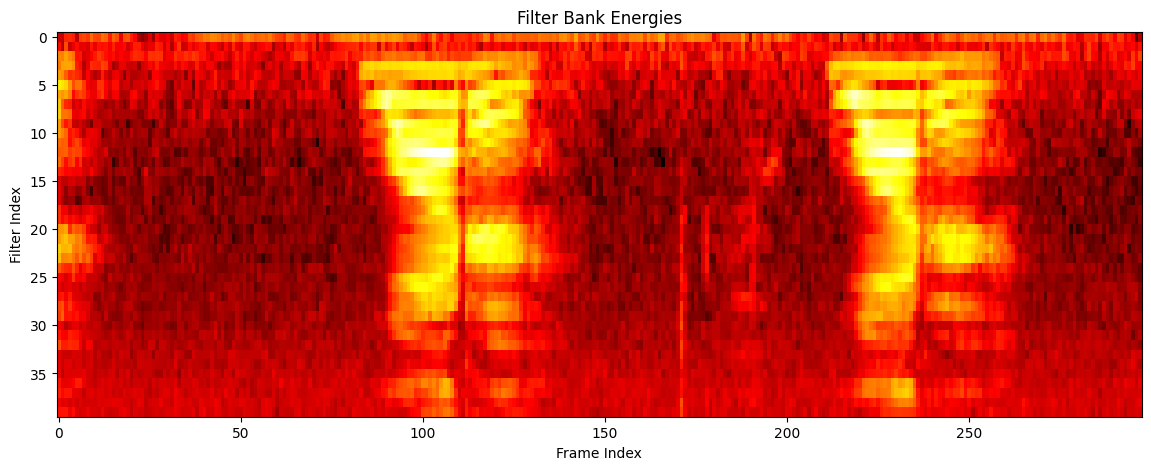

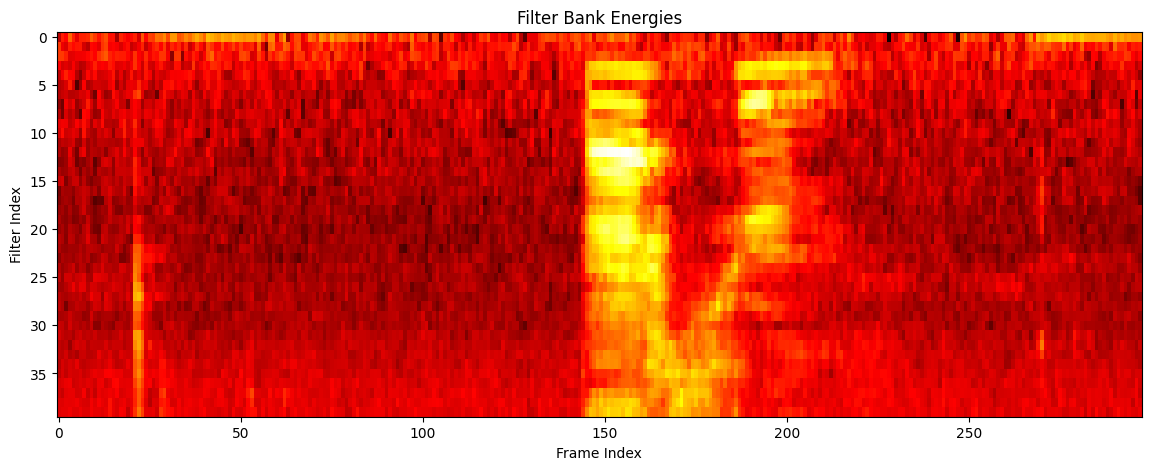

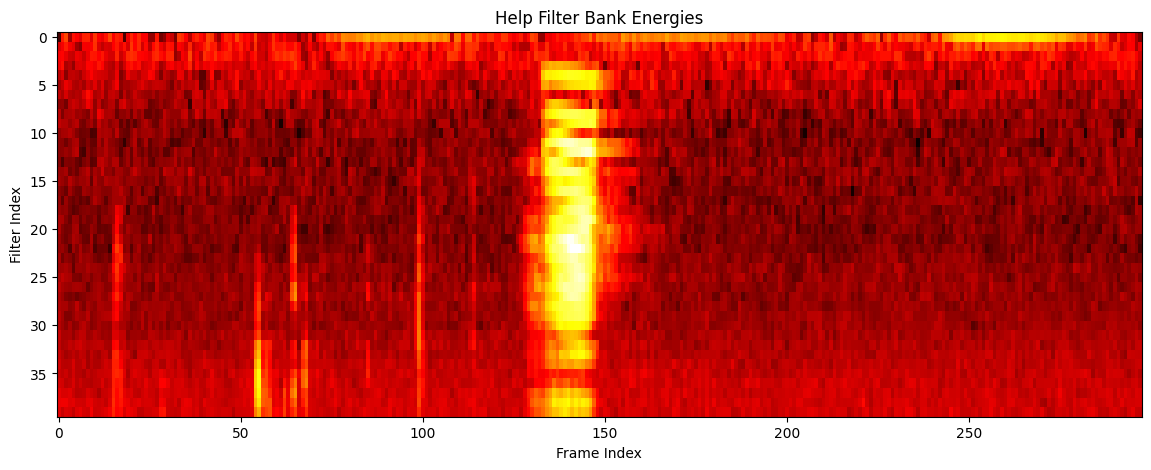

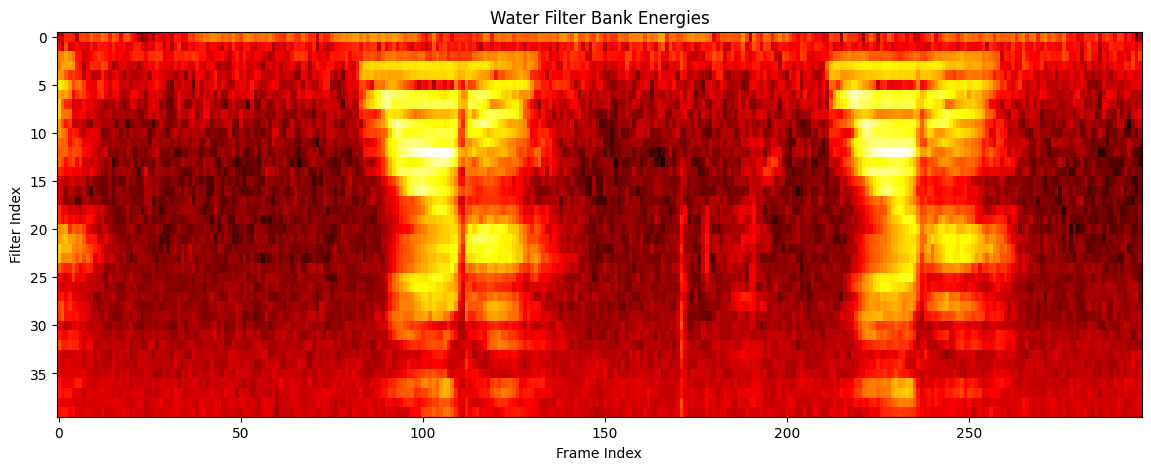

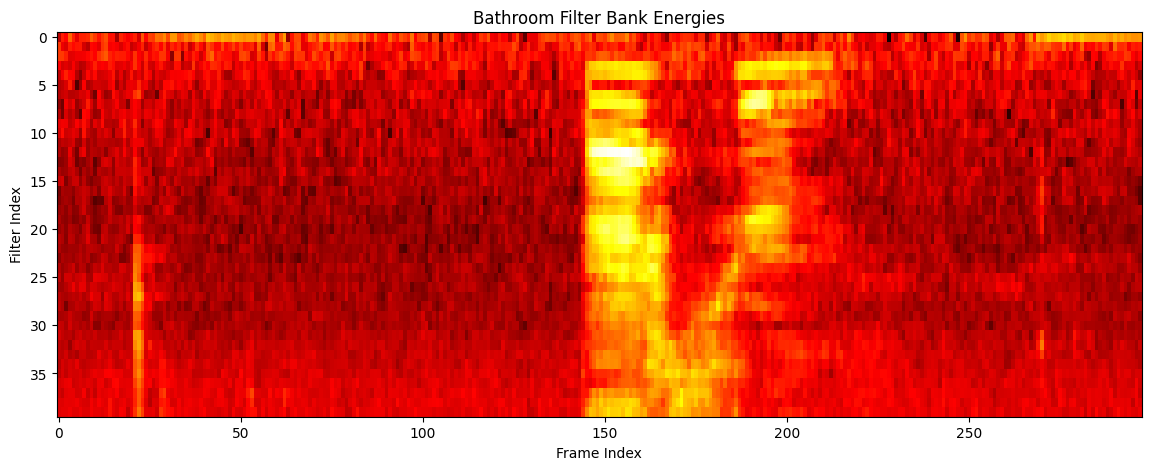

In [15]:
# Plot the filter bank energies
def plot_bank_energies(filter_banks, title="Filter Bank Energies"):
    plt.figure(figsize=(14, 5))
    plt.imshow(filter_banks.T, cmap='hot', aspect='auto')
    plt.title(title)
    plt.xlabel('Frame Index')
    plt.ylabel('Filter Index')
    plt.show()

for i in log_filter_banks:
    plot_bank_energies(i, "Filter Bank Energies")
    
plot_bank_energies(log_filter_banks[0], "Help Filter Bank Energies")
plot_bank_energies(log_filter_banks[1], "Water Filter Bank Energies")
plot_bank_energies(log_filter_banks[2], "Bathroom Filter Bank Energies")

# Step 8 - Compute MFCCs through Discrete Cosine Transform

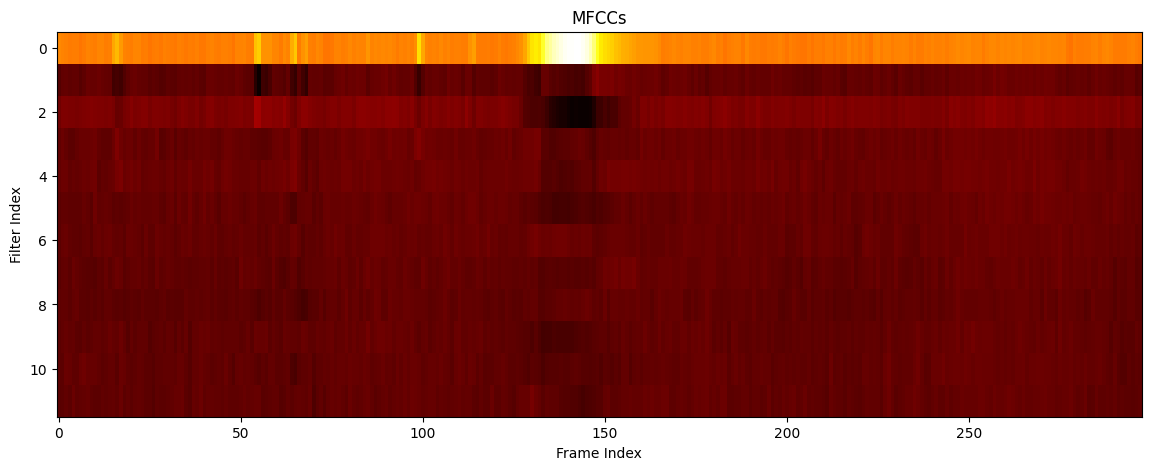

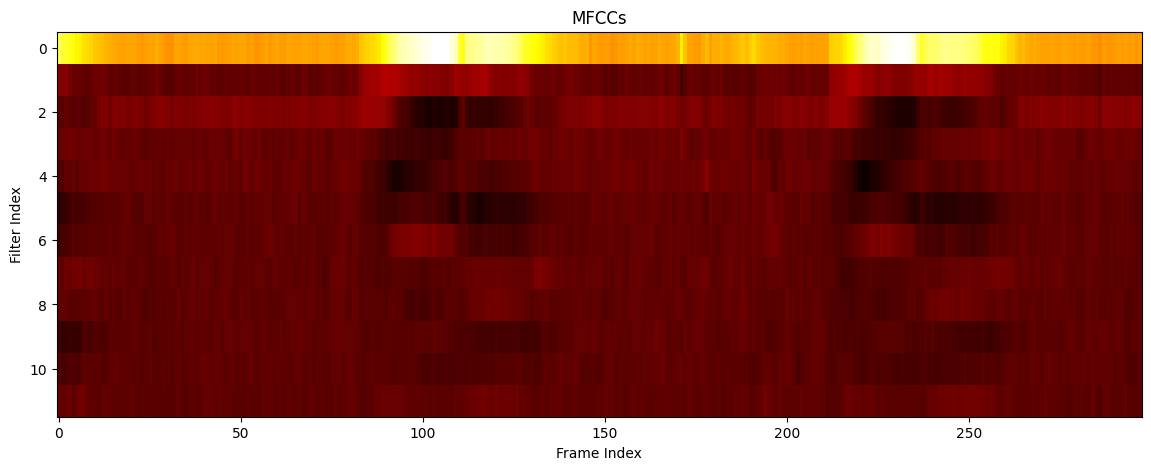

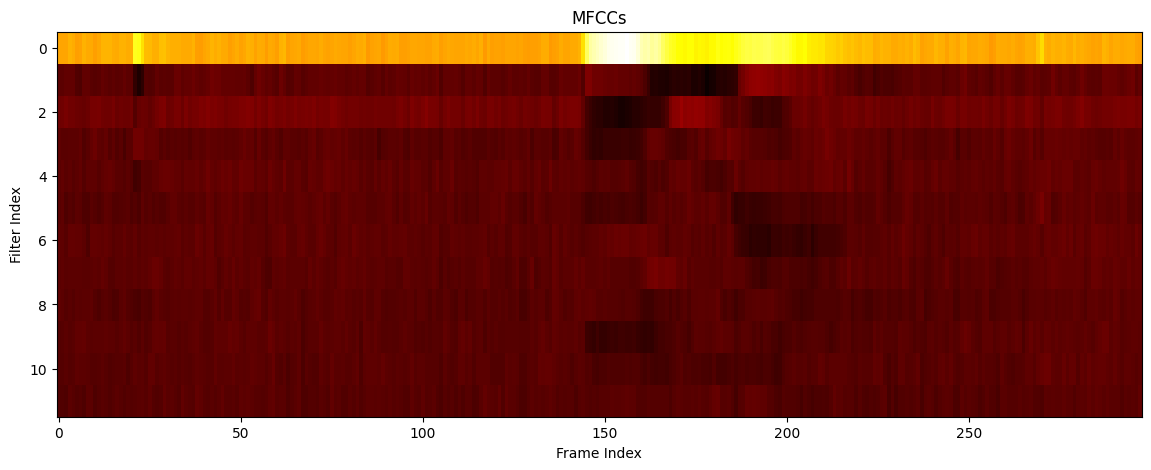

In [18]:
from scipy.fftpack import dct

num_ceps = 12
mfccs = [dct(bank, type=2, axis=1, norm='ortho')[:,:num_ceps] for bank in log_filter_banks]
# Plot the MFCCs
for i in mfccs:
    plot_bank_energies(i, "MFCCs")


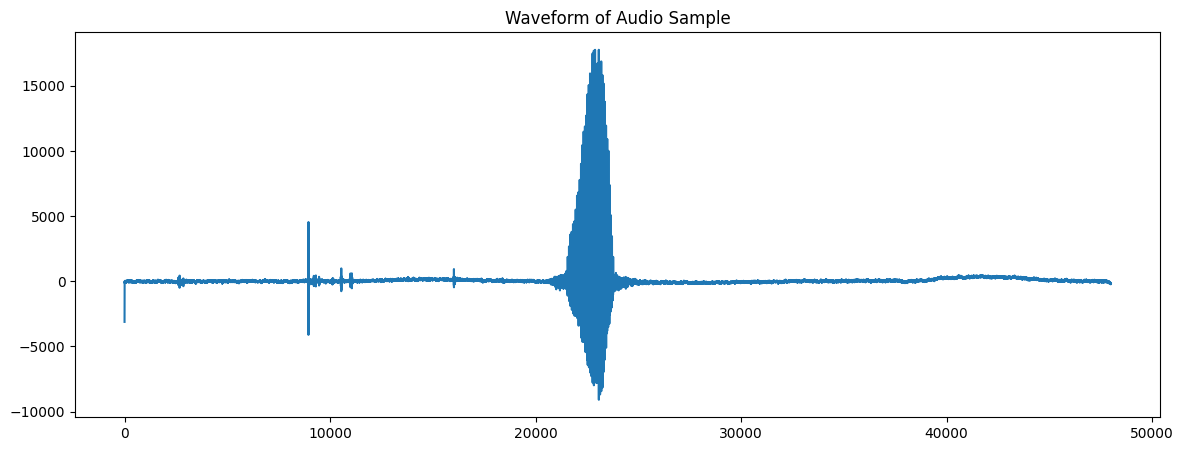

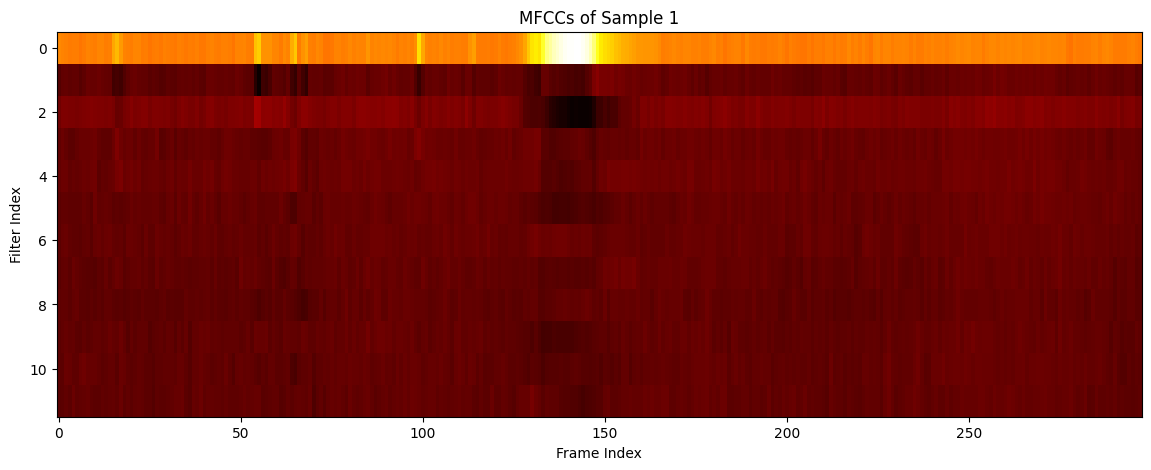

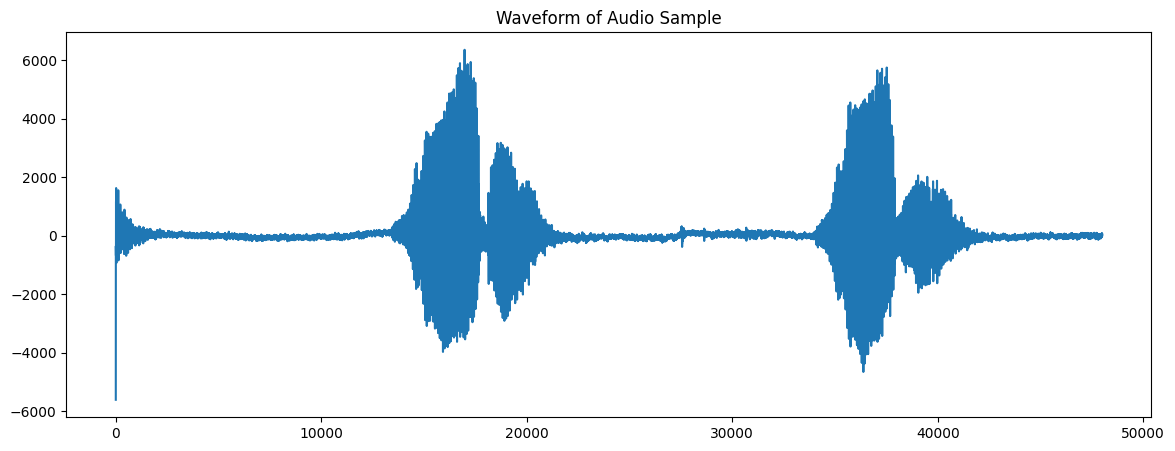

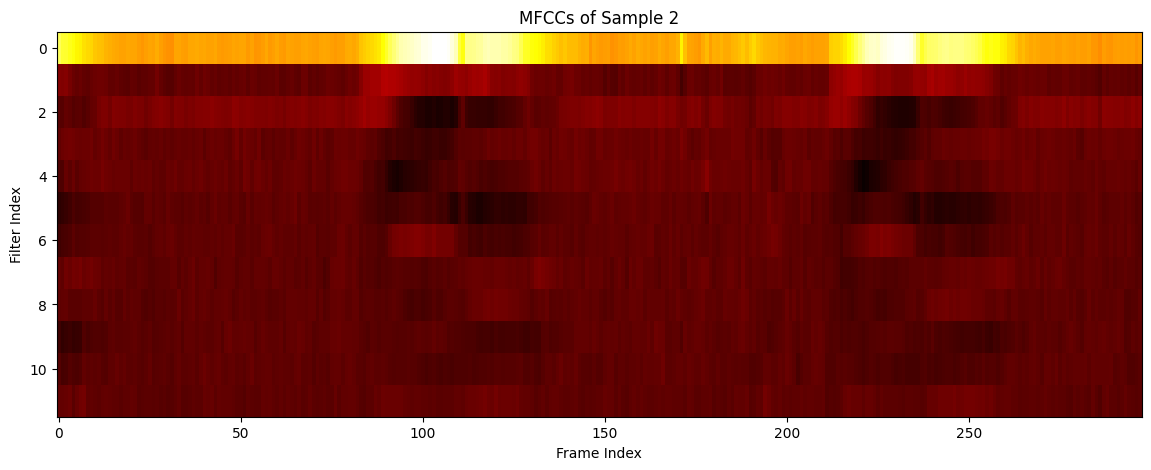

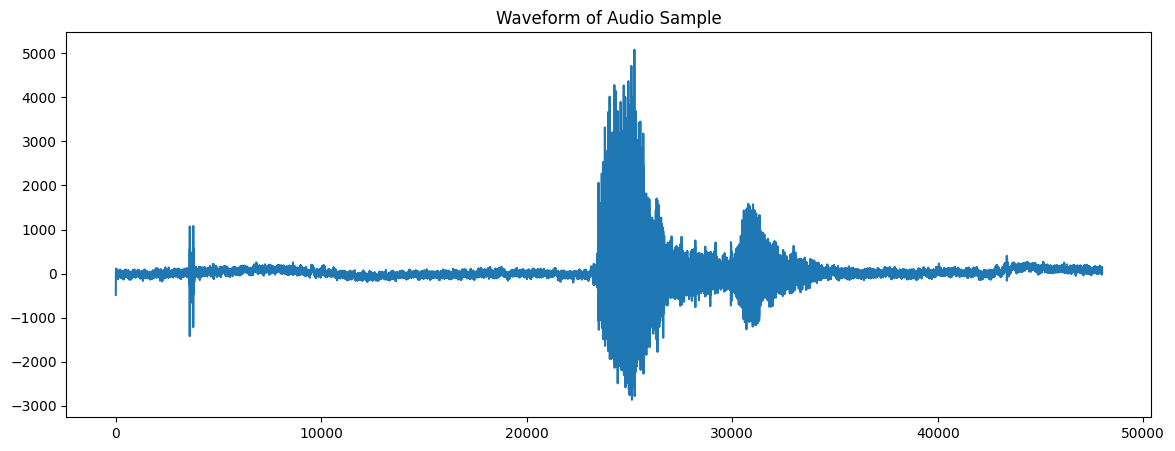

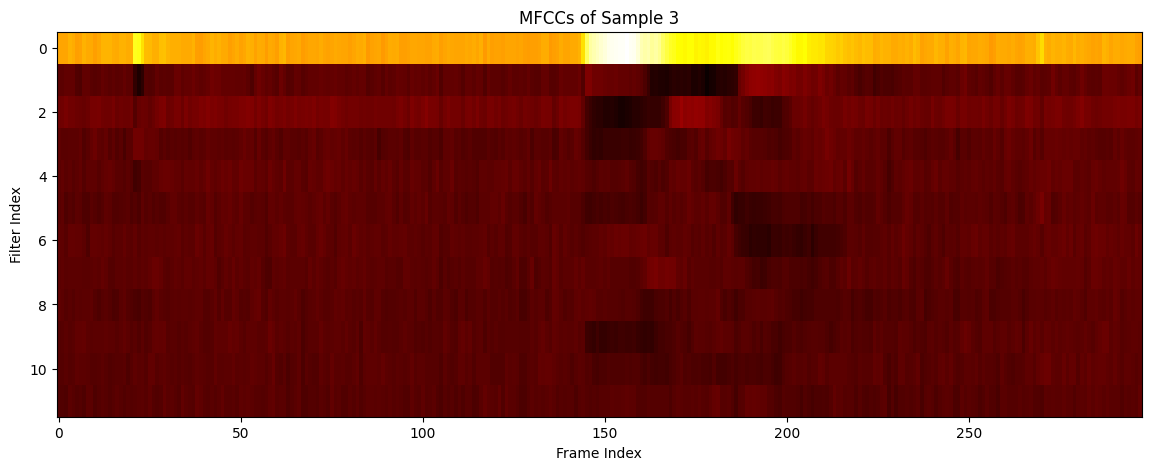

In [19]:
for i in range(len(mfccs)):
    plt.figure(figsize=(14, 5))
    plt.plot(emphasized_signals[i])
    plt.title("Waveform of Audio Sample")
    plot_bank_energies(mfccs[i], f"MFCCs of Sample {i+1}")